# Residuals as programs: a law no form language can write

Every other tutorial here writes a residual that a form language could also write. This one
does not, and that is the point.

hIPPyMFEM asks you for the weak form **at one quadrature point**, as a Python function. It is
differentiated by [JAX](https://docs.jax.dev), so whatever you can write in JAX is a residual:
a tabulated constitutive law read from measurements, a smooth switch, an inner Newton solve, a
neural closure. Nothing needs a symbolic representation, and nothing needs a new integrator.

Here the conductivity is **measured at twelve temperatures** and read back with a Gaussian
kernel, so $k$ depends on the state $u$ through a table rather than a formula:

$$ -\nabla\cdot\big(e^{m}\, k(u)\, \nabla u\big) = f \quad\text{in }\Omega=[0,1]^2,
\qquad u = 0 \ \text{on } \Gamma_{\rm left}\cup\Gamma_{\rm right}, $$

with $m$ the log of a spatially varying multiplier, the field we will infer from point
observations of $u$. The Jacobian, the adjoint and every Hessian block come from
differentiating that one function.

## 1. Load modules

In [1]:
import os
import sys

# Run from a source checkout without installing: the repository root is one level up.
sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem
import jax.numpy as jnp

import hippymfem as hm
from hippymfem import nb
from hippymfem.modeling.variables import STATE, PARAMETER, ADJOINT

## 2. Mesh, spaces and boundary conditions

The state is quadratic, the parameter linear, and the adjoint lives in the state space, which
is the triple `[STATE, PARAMETER, ADJOINT]` every hIPPyMFEM problem is built on.

In [2]:
n = 24
mesh = mfem.ParMesh(MPI.COMM_WORLD,
                    mfem.Mesh.MakeCartesian2D(n, n, mfem.Element.QUADRILATERAL))

Vh2 = hm.FunctionSpace.H1(mesh, 2)
Vh1 = hm.FunctionSpace.H1(mesh, 1)
Vh = [Vh2, Vh1, Vh2]

bottom, right, top, left = 1, 2, 3, 4
bc = hm.DirichletBC(Vh[STATE], 0.0, bdr_attributes=[left, right])
bc0 = hm.DirichletBC(Vh[STATE], 0.0, bdr_attributes=[left, right])

print("state dofs %d, parameter dofs %d"
      % (Vh[STATE].GlobalTrueVSize(), Vh[PARAMETER].GlobalTrueVSize()))

state dofs 2401, parameter dofs 625


## 3. The constitutive law, as data

Suppose conductivity was measured at twelve temperatures. To use it in a PDE it has to be a
smooth function of $u$, so we read the table with a Gaussian kernel: each node gets a weight,
and the weighted mean is the value. That is five lines of JAX, and it is differentiable in $u$
to every order the solver needs.

A form language would need this law as a built-in special function, or as an external operator
with hand-written derivatives. Here it is just code.

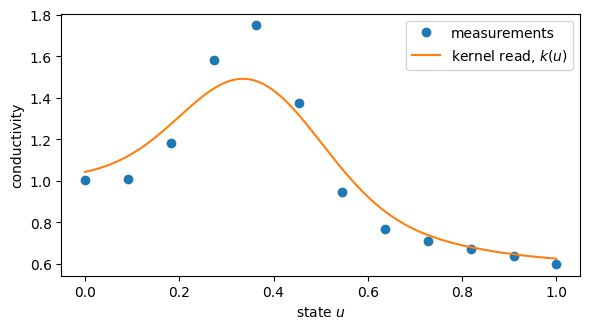

In [3]:
T_nodes = np.linspace(0.0, 1.0, 12)                      # the temperatures measured at
k_meas = 1.0 + 0.9 * np.exp(-((T_nodes - 0.35) / 0.15) ** 2) - 0.4 * T_nodes   # the measurements

nodes_j, tab_j = jnp.asarray(T_nodes), jnp.asarray(k_meas)
width = 1.2 * (T_nodes[1] - T_nodes[0])


def k_of(T):
    "The table, read with a Gaussian kernel: smooth in T, and differentiable."
    w = jnp.exp(-0.5 * ((T - nodes_j) / width) ** 2)
    return jnp.sum(w * tab_j) / jnp.sum(w)


Tfine = np.linspace(0.0, 1.0, 200)
plt.figure(figsize=(6, 3.4))
plt.plot(T_nodes, k_meas, "o", label="measurements")
plt.plot(Tfine, [float(k_of(t)) for t in Tfine], "-", label="kernel read, $k(u)$")
plt.xlabel("state $u$"); plt.ylabel("conductivity"); plt.legend(); plt.tight_layout()
plt.show()

## 4. The residual density

`pde_varf(u, m, p, x)` is the weak form at one quadrature point: `u`, `m` and `p` carry
`.val` and `.grad` there, and `x` is the physical point. The conductivity multiplies the
table read by $e^m$, so the parameter scales a law that itself depends on the state: the
problem is nonlinear in $u$ and in $m$.

`is_fwd_linear=False` tells the forward solver to run Newton's method, with the Jacobian it
gets by differentiating this same function.

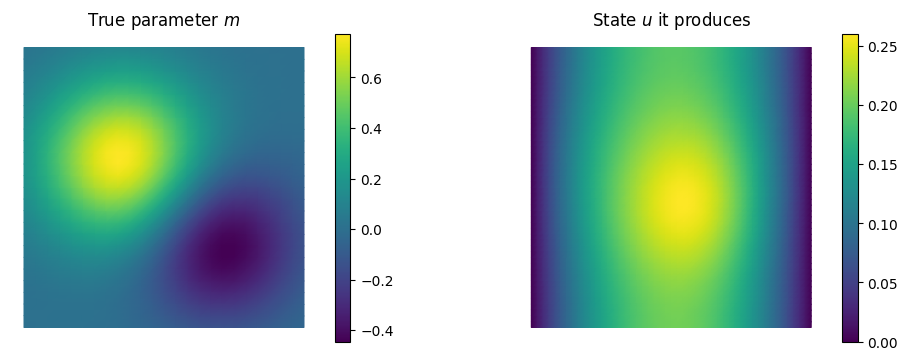

In [4]:
def f(x):
    return 1.0 + 8.0 * jnp.exp(-30.0 * ((x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2))


def pde_varf(u, m, p, x):
    k = jnp.exp(m.val) * k_of(u.val)
    return k * hm.inner(u.grad, p.grad) - f(x) * p.val


pde = hm.PDEVariationalProblem(Vh, pde_varf, bc, bc0, is_fwd_linear=False)

mtrue = Vh[PARAMETER].project(
    lambda x: 0.8 * np.exp(-12.0 * ((x[0] - 0.35) ** 2 + (x[1] - 0.6) ** 2))
    - 0.5 * np.exp(-14.0 * ((x[0] - 0.7) ** 2 + (x[1] - 0.3) ** 2)))

utrue = pde.generate_state()
pde.solveFwd(utrue, [utrue, mtrue, None])

plt.figure(figsize=(12, 4))
nb.plot(Vh[PARAMETER], mtrue, subplot_loc=121, mytitle="True parameter $m$")
nb.plot(Vh[STATE], utrue, subplot_loc=122, mytitle="State $u$ it produces")
plt.show()

## 5. Data, prior, model

Sixty-something point observations of $u$ with half a percent of noise, a BiLaplacian prior on
$m$, and the three together as a `Model`. Nothing here is specific to the tabulated law: once
the density is written, the rest of the library does not care how it was computed.

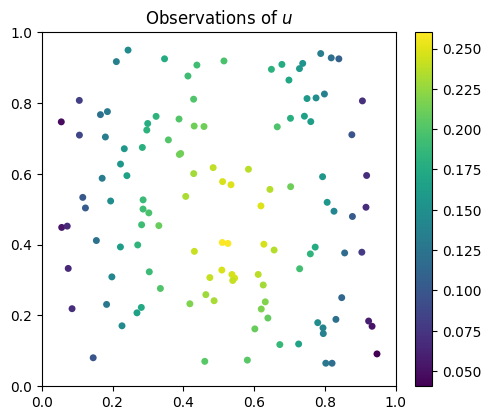

In [5]:
rng = np.random.default_rng(1)
targets = np.column_stack((rng.uniform(0.05, 0.95, 120), rng.uniform(0.05, 0.95, 120)))
B = hm.assemblePointwiseObservation(Vh[STATE], targets)

data = B.createVecLeft()
B.mult(utrue, data)
noise_std = 0.005 * data.norm("linf")
hm.parRandom.set_seed(2)
B.perturb(data, noise_std)

misfit = hm.DiscreteStateObservation(B, data, noise_std ** 2)
prior = hm.BiLaplacianPrior(Vh[PARAMETER], 1.0, 8.0, robin_bc=True)
model = hm.Model(pde, prior, misfit)

plt.figure(figsize=(6, 4.6))
nb.plot_pts(targets, B.gather(data), mytitle="Observations of $u$")
plt.show()

## 6. The derivatives nobody wrote

`modelVerify` perturbs the parameter and checks the gradient and the Hessian against finite
differences. A first-order slope of 1 in the left panel means the gradient is the derivative
of the cost, and the Hessian check on the right means the second derivatives agree too.

Those derivatives come from differentiating `pde_varf`. The table read, the exponential and
the inner product were differentiated together; no adjoint equation was written by hand, and
the law could be replaced with anything else differentiable without touching another line.

      eps  ||err grad||     ||err H||        J(m+h)       slope g


 1.00e+00  4.673495e+06  6.812777e+02  4.688558e+06             -


 5.00e-01  2.337027e+06  3.769399e+02  1.180253e+06        0.9998


 2.50e-01  1.168610e+06  1.863918e+02  3.022306e+05        0.9999


 1.25e-01  5.843309e+05  9.152837e+01  8.228858e+04        0.9999


...

 7.45e-09  3.160295e-02  1.058167e-03  8.416351e+03        1.1307


 3.73e-09  1.548967e-02  1.810731e-03  8.416351e+03        1.0288


 1.86e-09  1.817797e-03  3.193211e-03  8.416351e+03        3.0910


 9.31e-10  5.994703e-03  7.981280e-03  8.416351e+03       -1.7215


 4.66e-10  3.770922e-03  2.612965e-02  8.416351e+03        0.6688


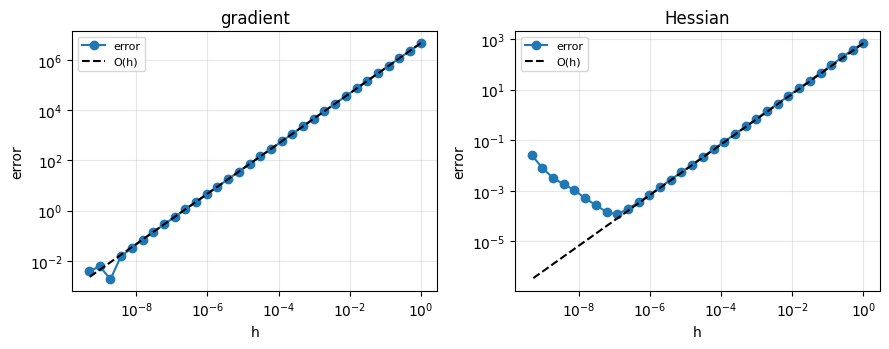

In [6]:
m0 = prior.mean.copy()
eps, err_grad, err_H = hm.modelVerify(model, m0, plotting=True)
plt.show()

## 7. The inverse problem

Inexact Newton-CG on the reduced problem: each CG iteration applies the reduced Hessian, which
is two incremental solves with the same blocks. The MAP point recovers the two bumps.

9 Newton iterations, 68 CG iterations, J = 1.3523e+02
relative error in m: 0.225  (Norm of the gradient less than tolerance)


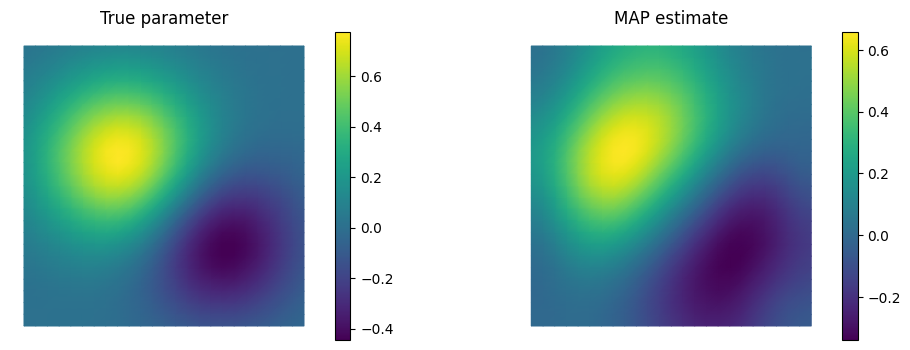

In [7]:
params = hm.ReducedSpaceNewtonCG_ParameterList()
params["rel_tolerance"] = 1e-8
params["max_iter"] = 12
params["print_level"] = -1

solver = hm.ReducedSpaceNewtonCG(model, params)
x = solver.solve([None, prior.mean.copy(), None])

err = mtrue.copy().axpy(-1.0, x[PARAMETER]).norm("l2") / mtrue.norm("l2")
print("%d Newton iterations, %d CG iterations, J = %.4e" % (
    solver.it, solver.total_cg_iter, solver.final_cost))
print("relative error in m: %.3f  (%s)" % (err, solver.termination_reasons[solver.reason]))

plt.figure(figsize=(12, 4))
nb.plot(Vh[PARAMETER], mtrue, subplot_loc=121, mytitle="True parameter")
nb.plot(Vh[PARAMETER], x[PARAMETER], subplot_loc=122, mytitle="MAP estimate")
plt.show()

## What to take from this

- The residual is a **program**, not a form. Any twice-differentiable JAX code is a valid
  density, which is what lets a measured, tabulated law sit inside the PDE.
- Every operator the inversion needs (Jacobian, adjoint, $C$, and the Hessian blocks) is
  generated from that one function, and `modelVerify` checks them against finite differences.
- Where an equivalent integrator does exist, the generated blocks agree with MFEM's own to
  about $10^{-15}$; the library's `test_kernels` suite makes that comparison on triangles,
  quadrilaterals, tetrahedra and hexahedra.

Next: [09_OnTheGPU](09_OnTheGPU.ipynb) moves this same machinery onto a GPU, and
[10_FacetsAndDG](10_FacetsAndDG.ipynb) writes densities on faces. The
`applications/geothermal` driver is this tutorial at basin scale in 3D, with a conductivity
table per lithology.